### Goal: 
backtest MA, Channel breakout and RSI strategies and compare to buy and hold

We assume that the yearly risk free rate is 5%. Hence, the daily risk free rate earned on cash is (1.05)^(1/250)-1 = 0.00019517970175764177. Cash positions (i.e. when not in a trade) will earn this.

In [140]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Portfolio Information:
Stocks: JSE Top 40, FirstRand, Sappi.
Start: 01/01/2014.
End: 31/12/2024.

In [141]:
data = pd.read_excel("data.xlsx")
tickers = ['jse', 'firstrand', 'sappi']
rfr = (1.05)**(1/250)-1

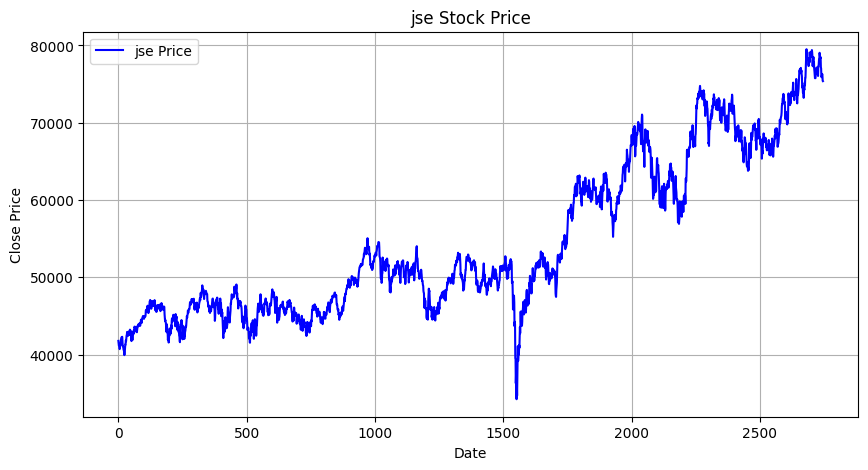

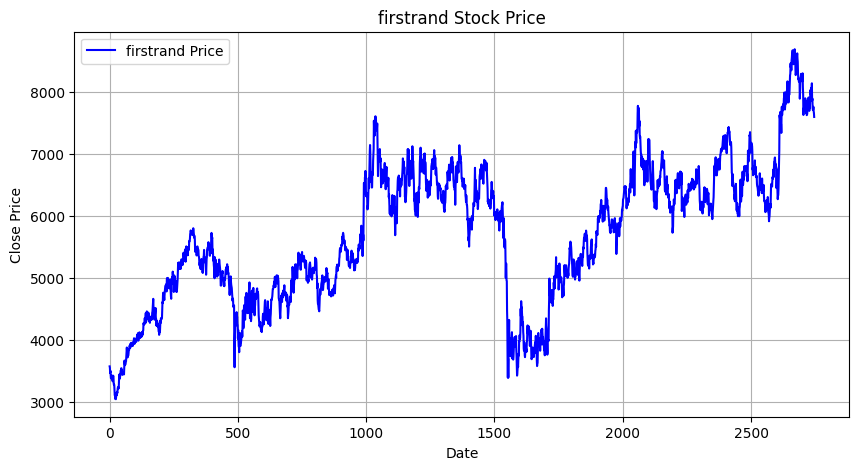

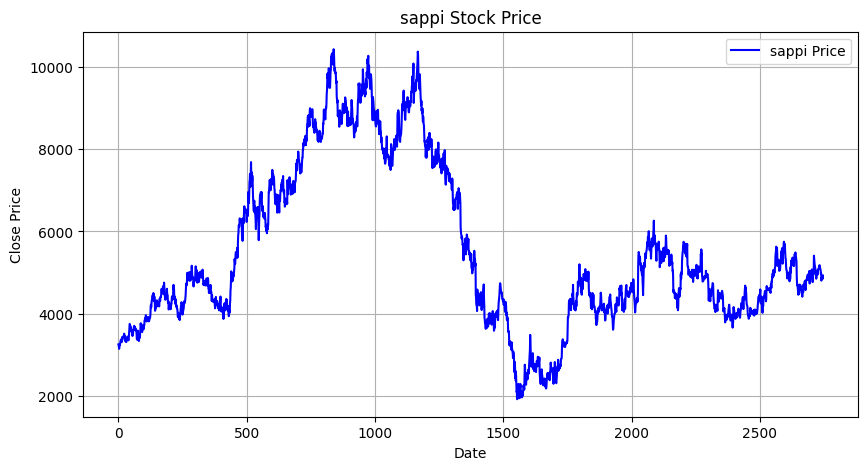

In [142]:
# plot price series
for ticker in tickers:
    plt.figure(figsize=(10, 5))
    plt.plot(data.index, data[ticker], label=f"{ticker} Price", color='blue')
    plt.title(f"{ticker} Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid()
    plt.show()



Function for calculation performance metrics:

In [143]:
def calculate_performance_metrics(results: dict[str, pd.DataFrame], daily_risk_free_rate = 0.00019517970175764177) -> pd.DataFrame:
    """
    Calculate performance metrics for a backtested strategy.
    
    Parameters:
        results (dict[str, pd.DataFrame]): Dictionary containing backtest results for each stock.
        
    Returns:
        pd.DataFrame: Performance metrics for each ticker.
    """
    metrics = []

    for ticker, df in results.items():
        df = df.copy()

        # Total Return (Cumulative Return)
        total_return = df["Portfolio_Value"].iloc[-1] - 1

        # Daily Return Standard Deviation
        daily_std = (df["Daily_Returns"]-daily_risk_free_rate).std()

        # Annualized Standard Deviation with square root of time rule (Assuming 252 trading days)
        annualized_std = daily_std * np.sqrt(252)

        # Sharpe Ratio (Annualized)
        excess_daily_returns = df["Daily_Returns"] - daily_risk_free_rate
        sharpe_ratio = excess_daily_returns.mean() / daily_std if daily_std > 0 else np.nan

        # Store results
        metrics.append([ticker, total_return, daily_std, annualized_std, sharpe_ratio])

    # Create a DataFrame with the results
    metrics_df = pd.DataFrame(metrics, columns=["Ticker", "Total Return", "Daily Std Dev", "Annualized Std Dev", "Sharpe Ratio"])
    metrics_df.set_index("Ticker", inplace=True)

    return metrics_df

### Moving Average:
- Buy if price moves above MA
- Sell when it drops back below

MA backtest function:

In [144]:
def ma_strat(prices: pd.DataFrame, ma_time: int, daily_risk_free_rate = 0.00019517970175764177):
    moving_ave = prices.rolling(window=ma_time).mean()
    results = {}

    for ticker in prices.columns:
        df = pd.DataFrame(index=prices.index)
        df["Price"] = prices[ticker]
        df["Moving_Avg"] = moving_ave[ticker]

        # Trading signals
        df["Signal"] = np.where(df["Price"] > df["Moving_Avg"], 1, 0)  # 1 = Buy/Hold, 0 = Sell

        # Shift signals to avoid lookahead bias
        df["Position"] = df["Signal"].shift(1)

        # Daily returns based on position
        df["Daily_Returns"] = df["Price"].pct_change() * df["Position"].shift(1)
        df.loc[df["Daily_Returns"] == 0, "Daily_Returns"] = daily_risk_free_rate
        df.iloc[:2, df.columns.get_loc("Daily_Returns")] = daily_risk_free_rate

        # Calculate portfolio value
        df["Portfolio_Value"] = (1 + df["Daily_Returns"]).cumprod()

        results[ticker] = df

        plt.figure(figsize=(12, 5))
        plt.plot(df.index, df["Portfolio_Value"], label=f"{ticker} Strategy", color="blue")
        plt.title(f"{ticker} {ma_time} day Moving Average Strategy Performance")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value")
        plt.legend()
        plt.grid()
        plt.show()

    return results

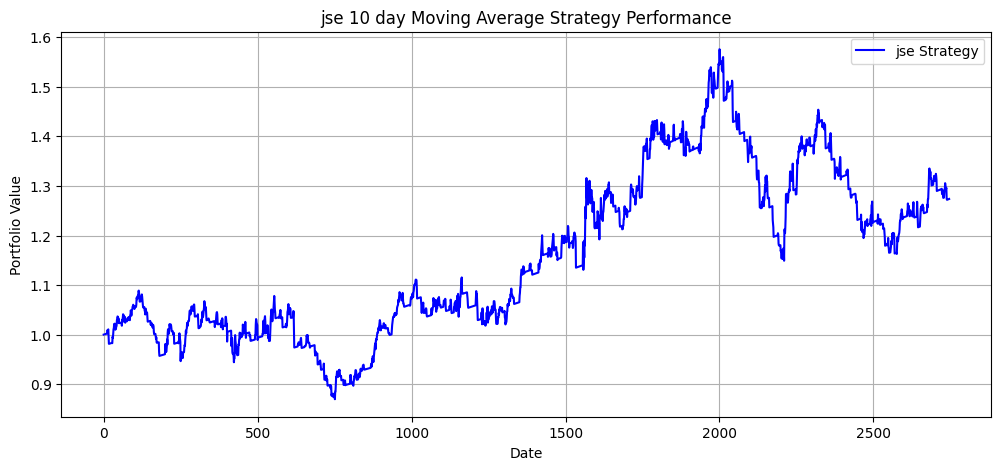

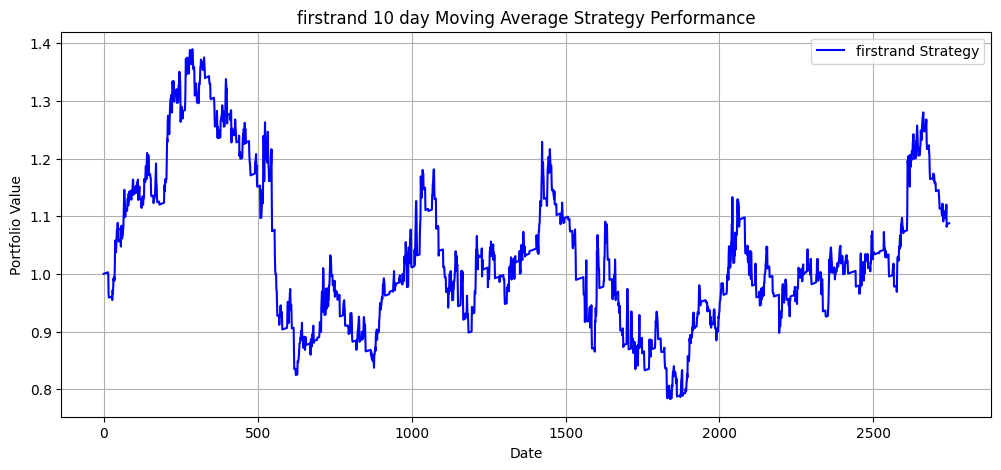

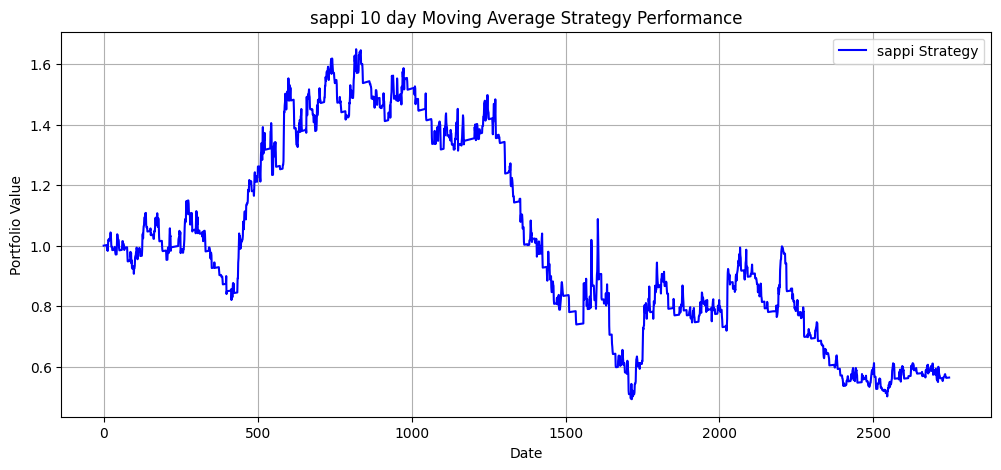

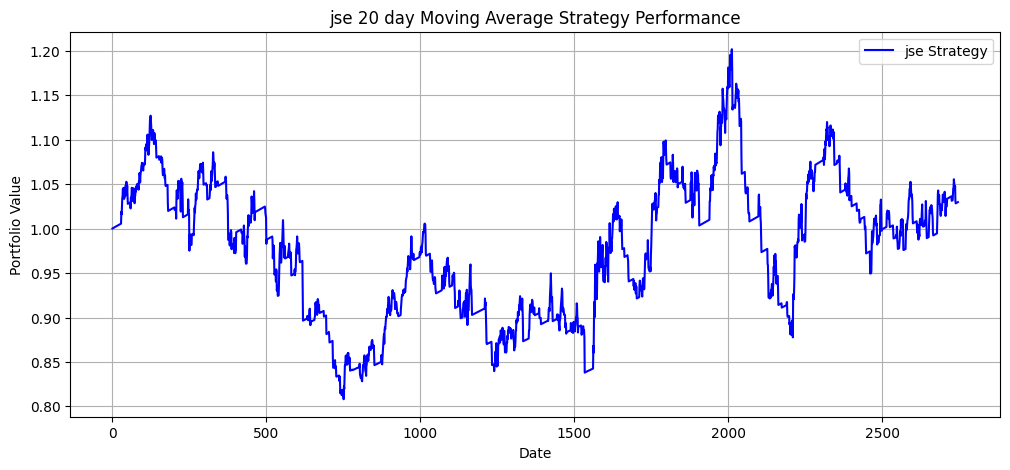

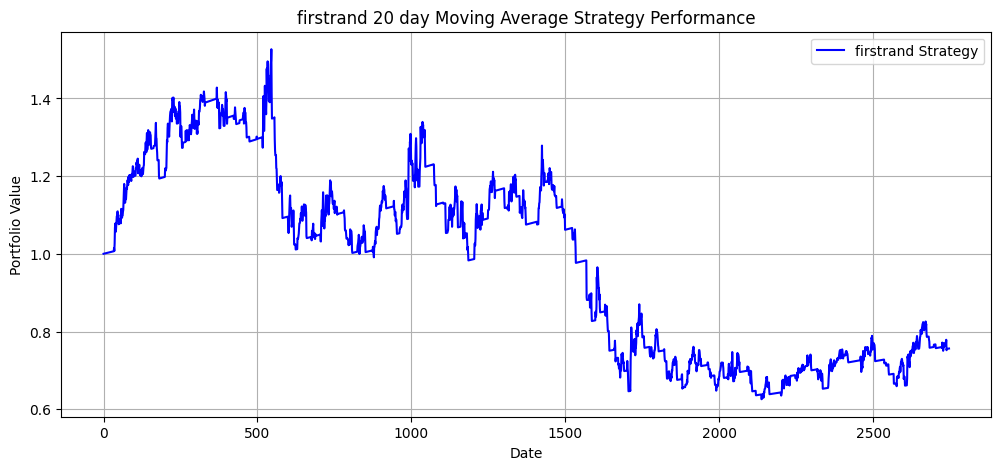

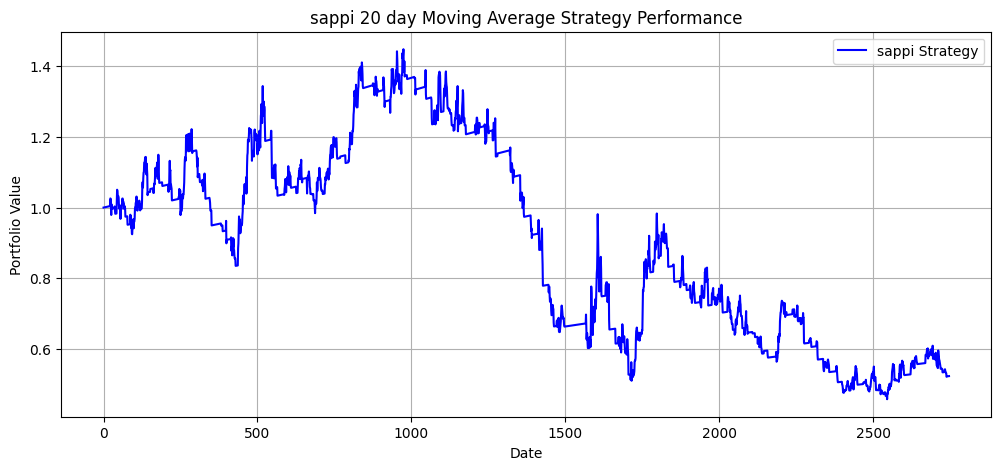

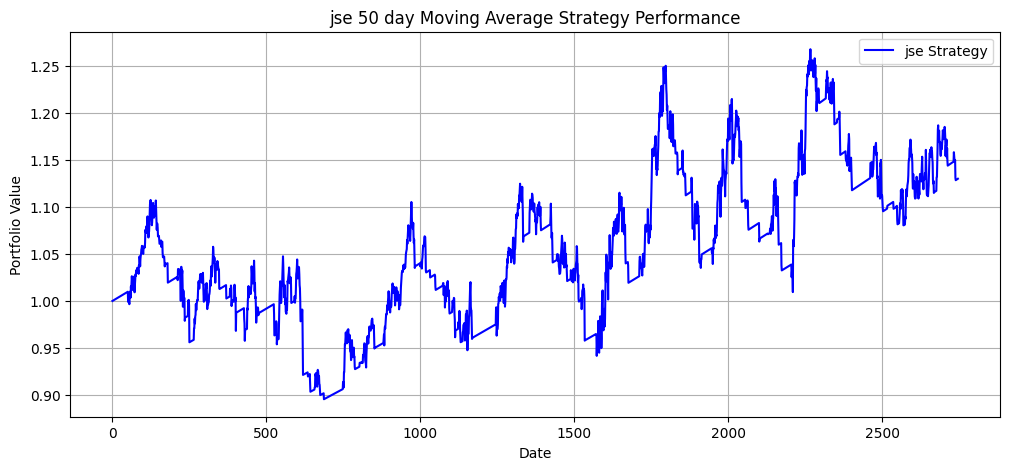

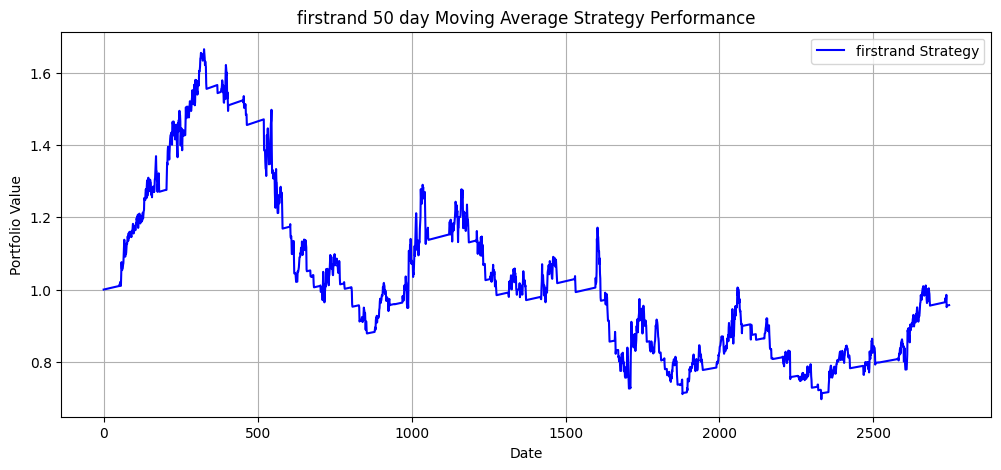

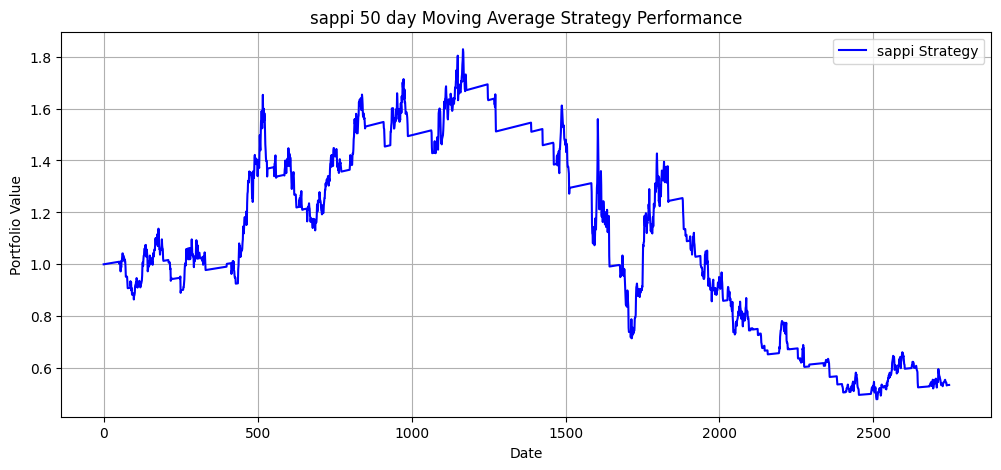

In [145]:
ma_strat_10 = ma_strat(prices=data[['jse', 'firstrand', 'sappi']], ma_time=10)
ma_strat_20 = ma_strat(prices=data[['jse', 'firstrand', 'sappi']], ma_time=20)
ma_strat_50 = ma_strat(prices=data[['jse', 'firstrand', 'sappi']], ma_time=50)

Calculate MA strat metrics:

In [146]:
calculate_performance_metrics(ma_strat_10)

,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,0.273687,0.007548,0.119821,-0.010414
firstrand,0.087917,0.013356,0.212017,-0.005642
sappi,-0.435610,0.018252,0.289736,-0.013024


In [147]:
calculate_performance_metrics(ma_strat_20)

,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,0.029895,0.007456,0.118364,-0.021010
firstrand,-0.243718,0.013580,0.215581,-0.015089
sappi,-0.476535,0.017771,0.282106,-0.015350


In [148]:
calculate_performance_metrics(ma_strat_50)

,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,0.130198,0.007289,0.115710,-0.017016
firstrand,-0.042903,0.013567,0.215371,-0.008805
sappi,-0.464395,0.017220,0.273355,-0.015895


### Breakout strategy:
- if price > max(previous 20 prices), go long
- if price < min(previous 20 prices), go short

Breakout strat backtest function:

In [149]:
def backtest_breakout_strategy(
    price_data: pd.DataFrame, 
    lookback: int = 20, 
    initial_capital: float = 1,
    daily_risk_free_rate = 0.00019517970175764177
) -> dict[str, pd.DataFrame]:
    """
    Backtest a 20-day breakout trading strategy with shorting and reversal exits.

    Parameters:
        price_data (pd.DataFrame): DataFrame containing stock closing prices.
        lookback (int): Number of days to calculate breakout high/low (default = 20).
        initial_capital (float): Starting capital for the strategy.

    Returns:
        dict[str, pd.DataFrame]: Dictionary containing backtest results for each stock.
    """
    results = {}

    for ticker in price_data.columns:
        df = pd.DataFrame(index=price_data.index)
        df["Price"] = price_data[ticker]

        # Compute rolling 20-day high & low
        df["20D_High"] = df["Price"].rolling(window=lookback).max()
        df["20D_Low"] = df["Price"].rolling(window=lookback).min()

        # Generate trading signals (Long = 1, Short = -1, Exit = 0)
        df["Signal"] = 0

        # Enter Long when price breaks above the 20-day high
        df.loc[df["Price"] > df["20D_High"].shift(1), "Signal"] = 1  

        # Enter Short when price breaks below the 20-day low
        df.loc[df["Price"] < df["20D_Low"].shift(1), "Signal"] = -1  

        # Exit Long if currently long and price drops back below the 20-day high
        df.loc[(df["Price"] < df["20D_High"].shift(1)) & (df["Signal"].shift(1) == 1), "Signal"] = 0  

        # Exit Short if currently short and price rises back above the 20-day low
        df.loc[(df["Price"] > df["20D_Low"].shift(1)) & (df["Signal"].shift(1) == -1), "Signal"] = 0  

        # Maintain position if no new signal
        df["Position"] = df["Signal"].shift(1)

        # Calculate daily returns
        df["Daily_Returns"] = df["Price"].pct_change() * df["Position"].shift(1)
        df.loc[df["Daily_Returns"] == 0, "Daily_Returns"] = daily_risk_free_rate
        df.iloc[:2, df.columns.get_loc("Daily_Returns")] = daily_risk_free_rate

        # Compute portfolio value
        df["Portfolio_Value"] = (1 + df["Daily_Returns"]).cumprod() * initial_capital

        results[ticker] = df

        # --- Plot: Portfolio Performance ---
        plt.figure(figsize=(12, 5))
        plt.plot(df.index, df["Portfolio_Value"], label=f"{ticker} Strategy Portfolio", color="blue")
        plt.title(f"{ticker} {lookback}-Day Breakout Strategy Performance")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value")
        plt.legend()
        plt.grid()
        plt.show()

    return results

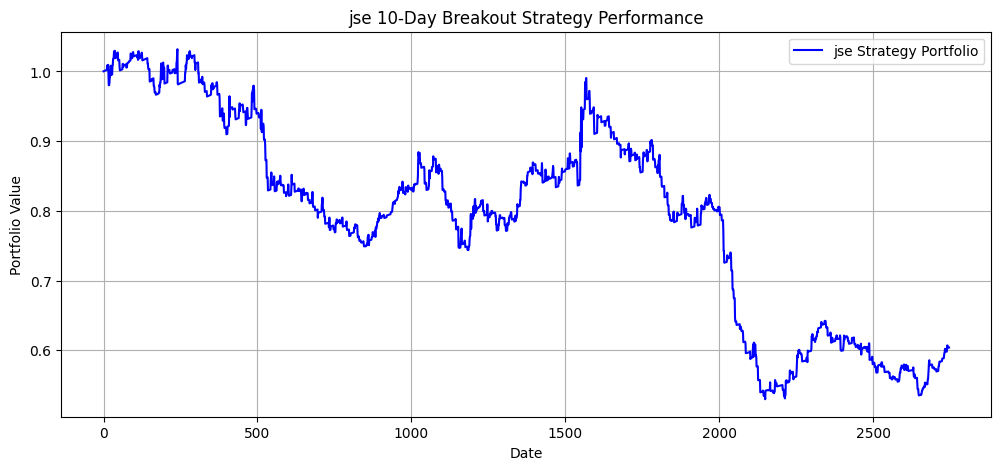

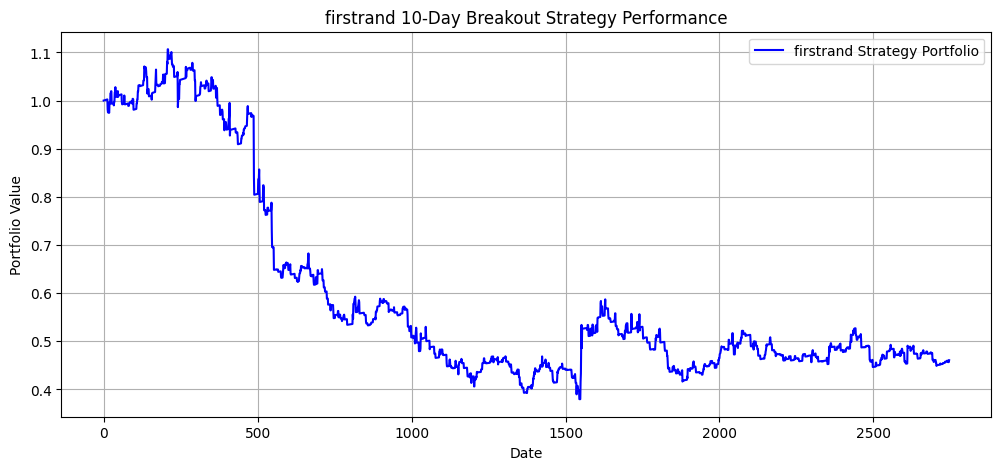

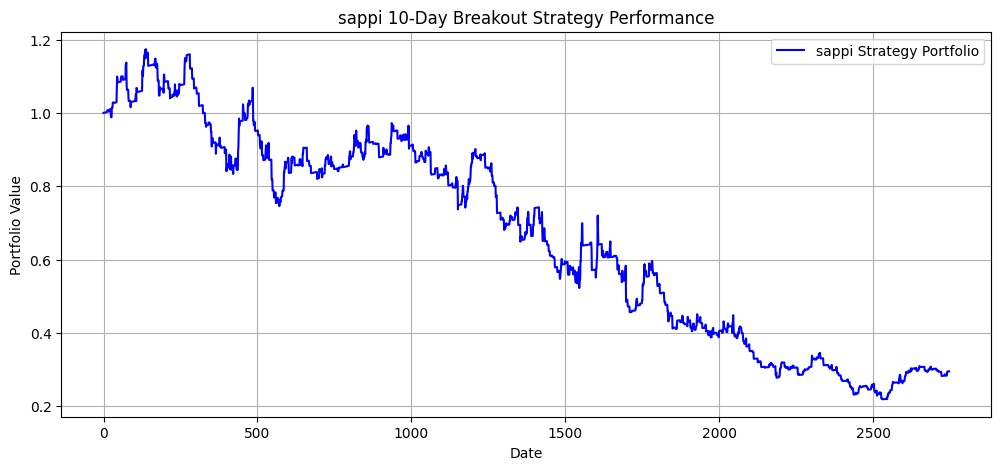

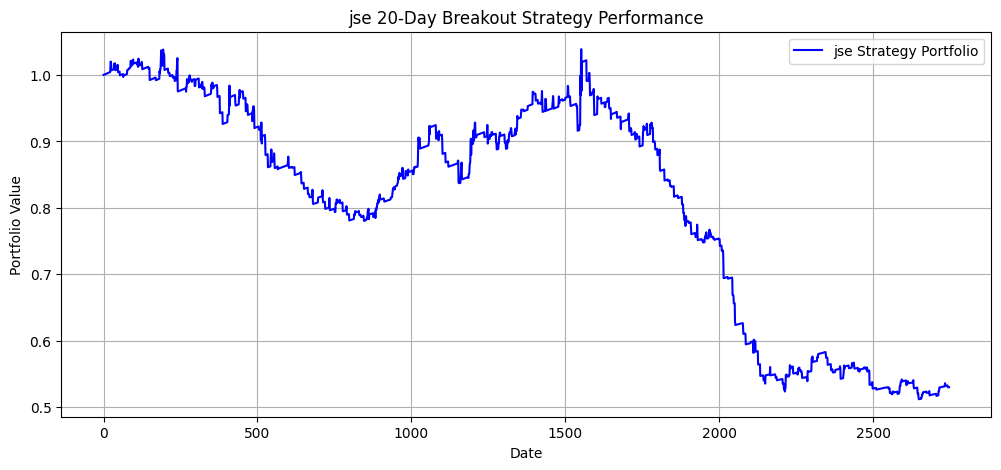

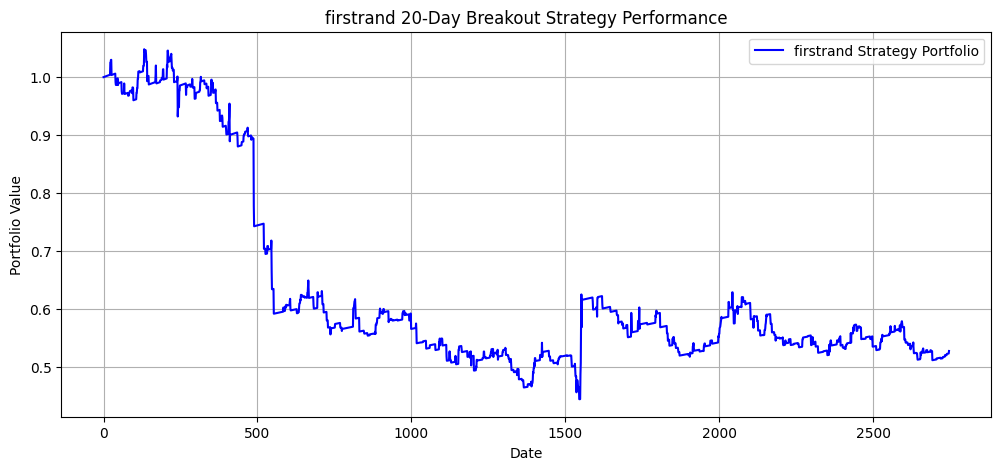

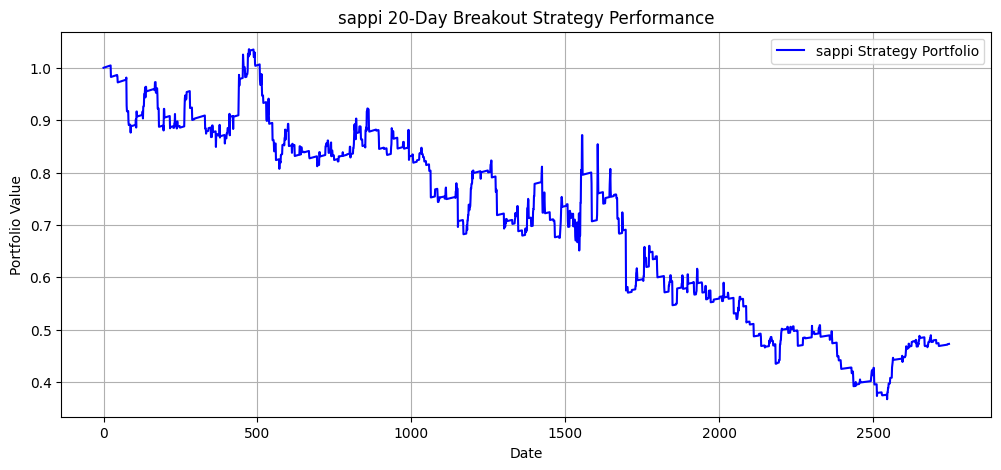

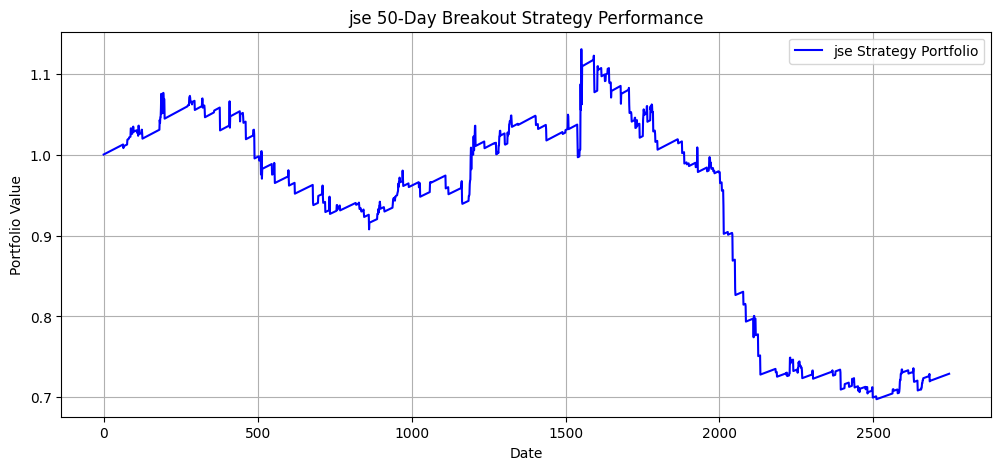

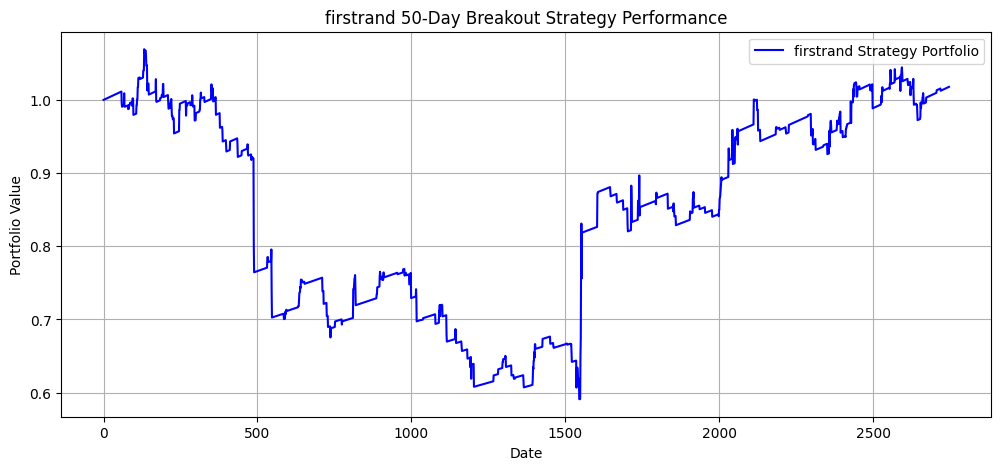

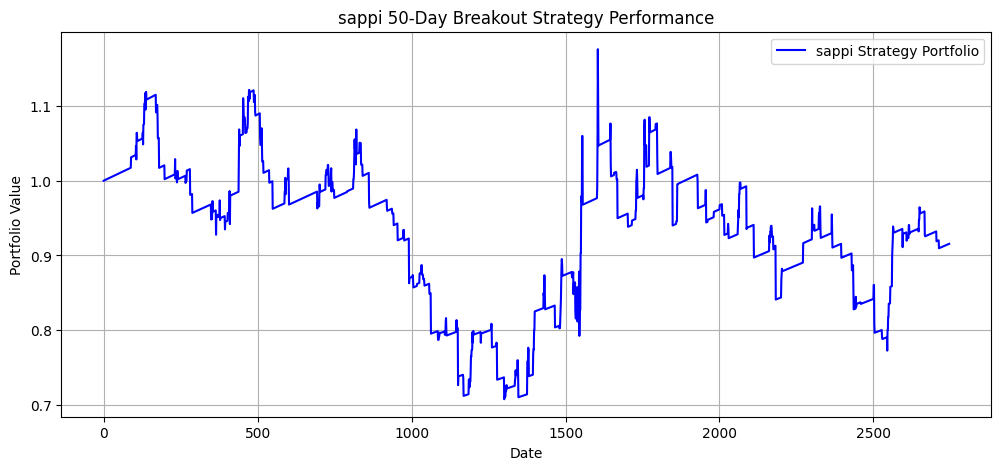

In [150]:
breakout_strat_10 = backtest_breakout_strategy(price_data=data[['jse', 'firstrand', 'sappi']], lookback=10)
breakout_strat_20 = backtest_breakout_strategy(price_data=data[['jse', 'firstrand', 'sappi']], lookback=20)
breakout_strat_50 = backtest_breakout_strategy(price_data=data[['jse', 'firstrand', 'sappi']], lookback=50)


Calculate breakout perfomance metrics:

In [151]:
calculate_performance_metrics(breakout_strat_10)

,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,-0.395989,0.006961,0.110499,-0.050926
firstrand,-0.539246,0.011461,0.181942,-0.035903
sappi,-0.705064,0.014573,0.231347,-0.036531


In [152]:
calculate_performance_metrics(breakout_strat_20)


,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,-0.470013,0.006105,0.096915,-0.066771
firstrand,-0.472209,0.009636,0.152962,-0.039568
sappi,-0.526991,0.012169,0.193170,-0.032275


In [153]:
calculate_performance_metrics(breakout_strat_50)

,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,-0.270941,0.004893,0.077666,-0.060964
firstrand,0.018035,0.008149,0.129363,-0.019086
sappi,-0.084435,0.009871,0.156695,-0.018083


### RSI strategy:
- buy if RSI<30
- short if RSI>70

RSI strat backtest function:

In [154]:
def backtest_rsi_strategy(price_data: pd.DataFrame, n = 14, daily_risk_free_rate = 0.00019517970175764177):
    results = {}

    for ticker in price_data.columns:
        df = pd.DataFrame(index=price_data.index)
        df["Price"] = price_data[ticker]
        df["Change"] = df["Price"].diff()
        df["RSI"] = None

        positive_changes = df["Change"].where(df["Change"] > 0)
        negative_changes = df["Change"].where(df["Change"] < 0) 

        rolling_mean_pos = positive_changes.rolling(window=n, min_periods=1).mean()
        rolling_mean_neg = negative_changes.abs().rolling(window=n, min_periods=1).mean()

        ratio = rolling_mean_pos/rolling_mean_neg
        df["RSI"] = 100 - 100/(1 + ratio)

        df.loc[df.index[:n], "RSI"] = np.nan

        # Define signals: 1 = Long, -1 = Short, 0 = No Position
        df["Signal"] = 0

        # Buy when RSI < 30
        df.loc[df["RSI"] < 30, "Signal"] = 1

        # Exit long position when RSI > 30
        df.loc[(df["Signal"].shift(1) == 1) & (df["RSI"] > 30), "Signal"] = 0

        # Short when RSI > 70
        df.loc[df["RSI"] > 70, "Signal"] = -1

        # Exit short position when RSI < 70
        df.loc[(df["Signal"].shift(1) == -1) & (df["RSI"] < 70), "Signal"] = 0

        # Maintain position if no new signal
        df["Position"] = df["Signal"].shift(1)

        # Calculate daily returns
        df["Daily_Returns"] = df["Price"].pct_change() * df["Position"].shift(1)
        df.loc[df["Daily_Returns"] == 0, "Daily_Returns"] = daily_risk_free_rate
        df.iloc[:2, df.columns.get_loc("Daily_Returns")] = daily_risk_free_rate
        df["Portfolio_Value"] = (1 + df["Daily_Returns"]).cumprod()
        # Plot results
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # Price plot
        ax1.plot(df.index, df["Price"], label="Price", color="blue")
        ax1.scatter(df.index[df["Signal"] == 1], df["Price"][df["Signal"] == 1], label="Long Entry", color="green", marker="^", alpha=1)
        ax1.scatter(df.index[df["Signal"] == -1], df["Price"][df["Signal"] == -1], label="Short Entry", color="red", marker="v", alpha=1)
        ax1.set_ylabel("Price")
        ax1.set_title("RSI Trading Strategy - Price Chart")
        ax1.legend()

        # RSI plot
        ax2.plot(df.index, df["RSI"], label="RSI", color="purple")
        ax2.axhline(70, linestyle="--", color="red", alpha=0.7)
        ax2.axhline(30, linestyle="--", color="green", alpha=0.7)
        ax2.set_ylabel("RSI")
        ax2.set_xlabel("Date")
        ax2.set_title("RSI Indicator")
        ax2.legend()

        plt.tight_layout()
        plt.show()

        # --- Plot: Portfolio Performance ---
        plt.figure(figsize=(12, 5))
        plt.plot(df.index, df["Portfolio_Value"], label=f"{ticker} Strategy Portfolio", color="blue")
        plt.title(f"{ticker} RSI Strategy Performance")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value")
        plt.legend()
        plt.grid()
        plt.show()

        results[ticker] = df
    return results

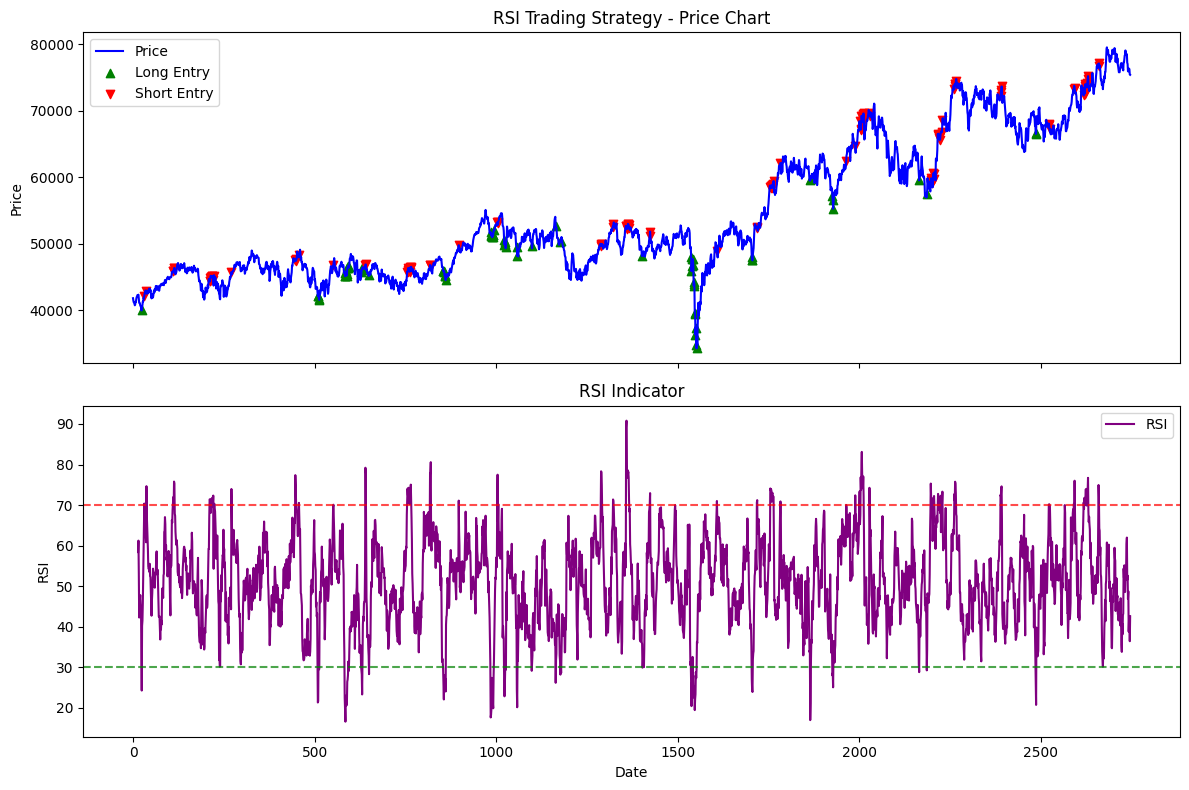

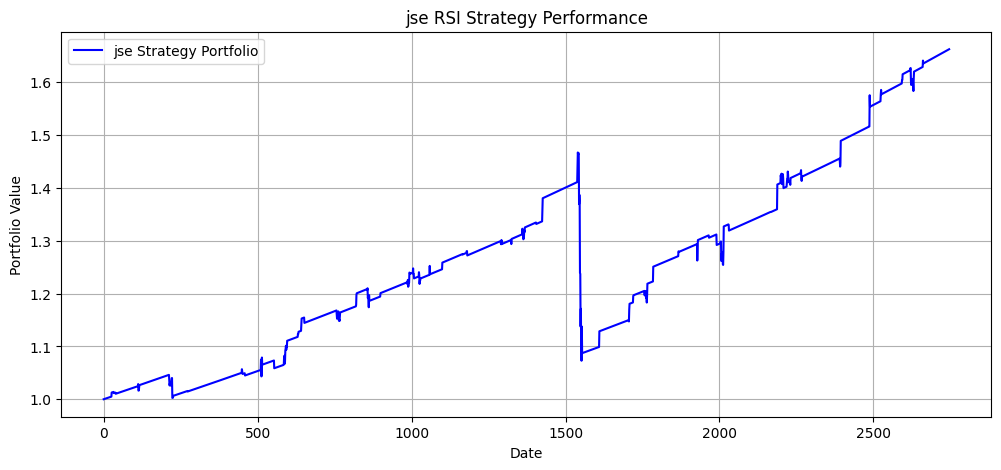

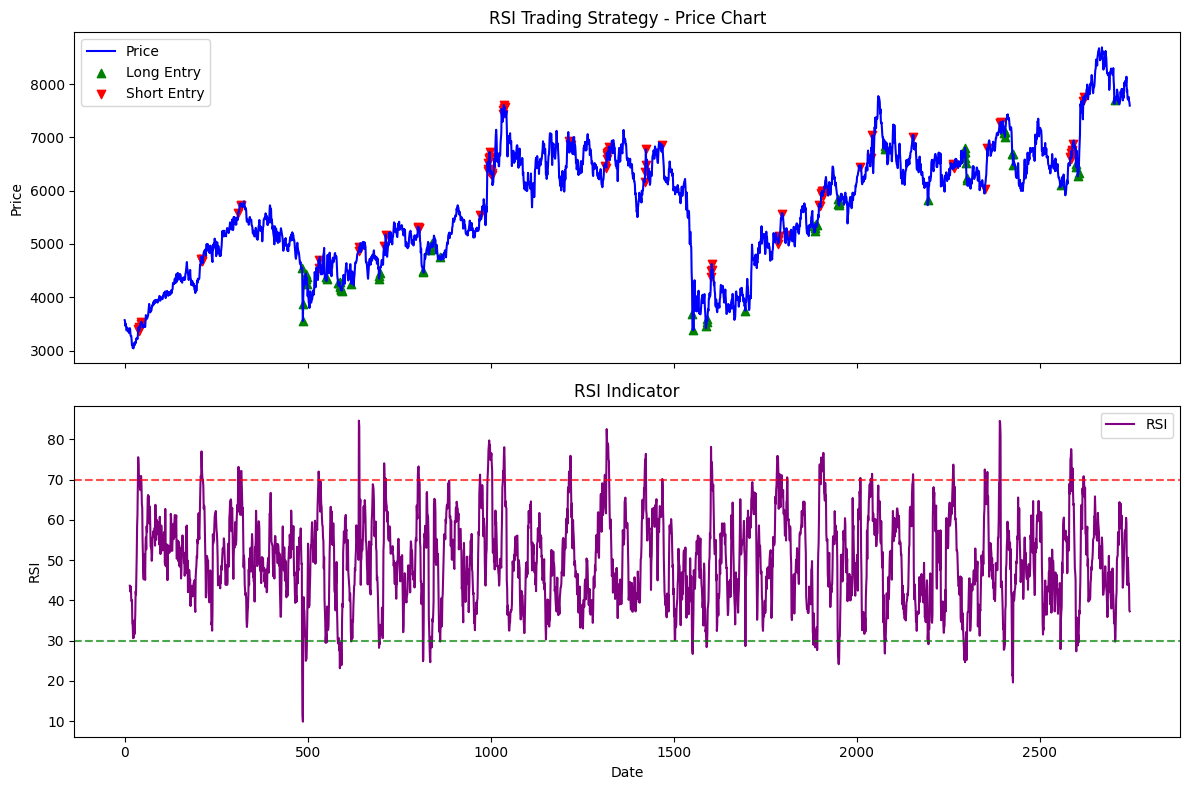

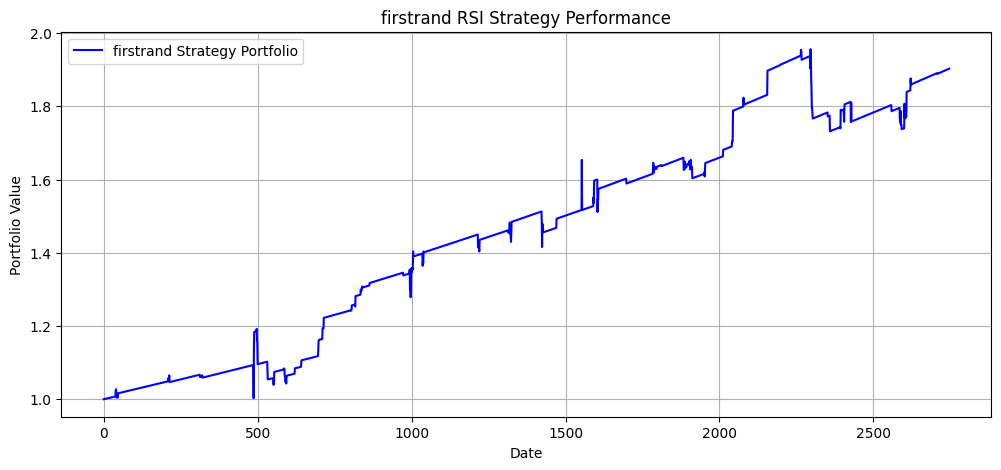

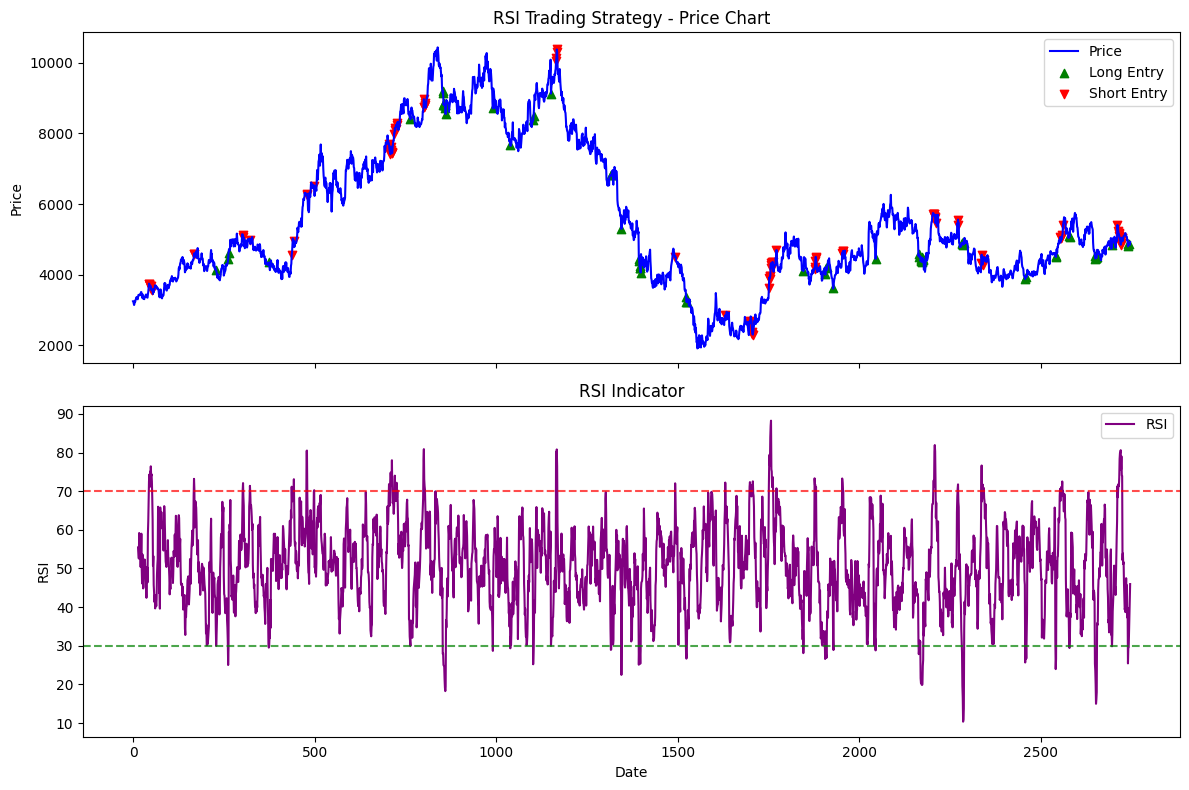

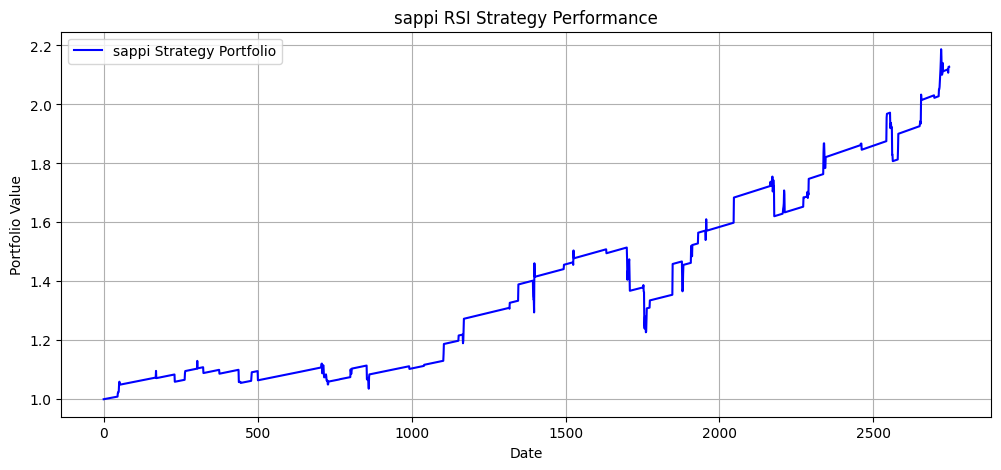

In [155]:
rsi_strat = backtest_rsi_strategy(data[['jse', 'firstrand', 'sappi']])


RSI strat metrics:

In [156]:
calculate_performance_metrics(rsi_strat)

,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,0.661858,0.004533,0.071966,0.000056
firstrand,0.902947,0.005797,0.092018,0.009604
sappi,1.128068,0.006111,0.097004,0.016077


### Buy and Hold:

In [157]:
buy_and_hold_strat = data[['jse', 'firstrand', 'sappi']].pct_change()


In [158]:
port = {}
for ticker in buy_and_hold_strat.columns:
    df = pd.DataFrame(index=buy_and_hold_strat.index)
    df["Daily_Returns"] = buy_and_hold_strat[ticker]
    df["Portfolio_Value"] = (1+buy_and_hold_strat[ticker]).cumprod()
    port[ticker] = df


Buy and hold metrics:

In [159]:
calculate_performance_metrics(port)

,Total Return,Daily Std Dev,Annualized Std Dev,Sharpe Ratio
Ticker,,,,
jse,0.803986,0.011574,0.183734,0.007501
firstrand,1.127135,0.019998,0.317461,0.013996
sappi,0.515692,0.025617,0.406654,0.011042
